# NUTDTS 816 · Assignment 1: Exploratory analysis and decomposition (7%)

Due Monday 21 September 2026, 23:59 WAT. Series A: nigeria_cpi. Series B: Austourists.

**Name / Group:** Fregene Ofe Favour  **Date:** 20-09-2026

This notebook must run top to bottom from a fresh Colab runtime. Keep the section headings; put your commentary in the markdown cells and your code in the code cells. Finish with the AI-use statement.

In [1]:
# ---- Setup: run once per Colab session ----
# 1. Install the course libraries (about two minutes the first time)
!pip install -q statsmodels pmdarima statsforecast neuralforecast lightgbm arch plotly

# 2. Fetch the course data module and data snapshots from the course repository.
#    Replace REPO with your fork or the official course repository URL.
REPO = "https://raw.githubusercontent.com/Favour-Fregene/NUTDTS816_Course_Repository/main"
import urllib.request, os
os.makedirs("data", exist_ok=True)
urllib.request.urlretrieve(f"{REPO}/src/tsdata.py", "tsdata.py")
DATA_FILES = ["nigeria_cpi", "austourists"]
for f in DATA_FILES:
    urllib.request.urlretrieve(f"{REPO}/data/{f}.csv", f"data/{f}.csv")

import warnings; warnings.filterwarnings("ignore")
import pandas as pd, numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 3.6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
import tsdata
print("Setup complete.")

Setup complete.


## 1. Load and tidy (DatetimeIndex, frequency, gaps)

*tsdata loaders; asfreq; explain any gap handling*

In [2]:
cpi = tsdata.nigeria_cpi()      # Fetch the Cpi data
print(type(cpi), cpi.index.freq)
print(cpi.head(6))
print(cpi.index[:3])

print()
print('-' * 40)
print()

at = tsdata.austourists()      # Fetch the austourists data
print(type(at), at.index.freq)
print(at.head(6))
print(at.index[:3])


<class 'pandas.core.series.Series'> <MonthBegin>
date
2014-01-01    20.1179
2014-02-01    20.2179
2014-03-01    20.3766
2014-04-01    20.5019
2014-05-01    20.6615
2014-06-01    20.8214
Freq: MS, Name: cpi, dtype: float64
DatetimeIndex(['2014-01-01', '2014-02-01', '2014-03-01'], dtype='datetime64[ns]', name='date', freq='MS')

----------------------------------------

<class 'pandas.core.series.Series'> <QuarterBegin: startingMonth=1>
date
1999-01-01    30.052513
1999-04-01    19.148496
1999-07-01    25.317692
1999-10-01    27.591437
2000-01-01    32.076456
2000-04-01    23.487961
Freq: QS-JAN, Name: tourists, dtype: float64
DatetimeIndex(['1999-01-01', '1999-04-01', '1999-07-01'], dtype='datetime64[ns]', name='date', freq='QS-JAN')


In [3]:
#Check for duplicate for both data
at_duplicate = at.index.duplicated().sum()
print("Total A.T Duplicate:", at_duplicate)

cpi_duplicate = cpi.index.duplicated().sum()
print("Total CPI Duplicate:", cpi_duplicate)

Total A.T Duplicate: 0
Total CPI Duplicate: 0


In [4]:
#Check for missing values for both data
at_isnull = at.isnull().sum()
print("Total A.T missing value:", at_isnull)

cpi_isnull = cpi.isnull().sum()
print("Total CPI missing value:", cpi_isnull)

Total A.T missing value: 0
Total CPI missing value: 0


Commentary:
*   Nigeria CPI: Monthly Data(MS, Period;12), a sorted DateTimeIndex stating from 2014-01-01. No gaps(missings values) or duplicate values found, so no imputation was needed.
*   Austourits: Quaterly Data(QS, Period;4), a sorted DateTimeIndex stating from 1999-01-01. No gaps(missings values) or duplicate values found, so no imputation was needed.



## 2. Time, seasonal, subseries and lag plots for each series

*one figure per plot type; annotate what each shows*

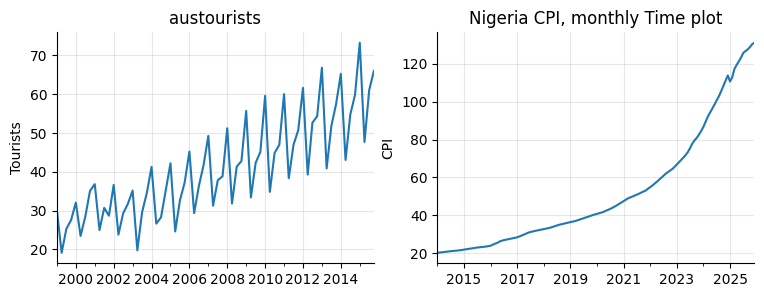

In [5]:
# Time Plot for both Series
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
at.plot(ax=axes[0], title='austourists', ylabel= 'Tourists', xlabel= 'Year')
cpi.plot(ax=axes[1], title='Nigeria CPI, monthly Time plot', ylabel='CPI', xlabel='Year')
for ax in axes.flat: ax.set_xlabel('')


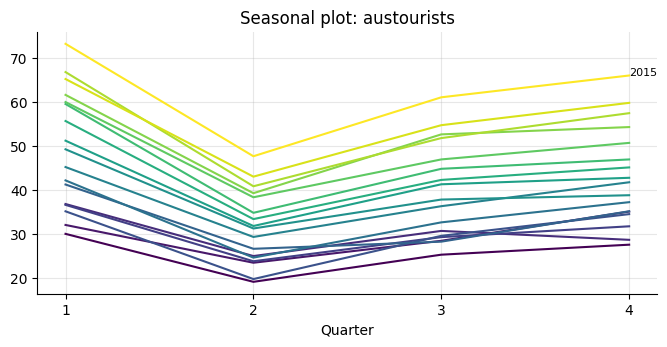

In [6]:
# Seasonal Plot for Austourists
def seasonal_plot(s, title=''):
    is_q = s.index.freqstr.startswith('Q')
    per = s.index.quarter if is_q else s.index.month
    n = 4 if is_q else 12
    df = pd.DataFrame({'v': s.values, 'year': s.index.year, 'p': per})
    piv = df.pivot(index='p', columns='year', values='v')
    ax = piv.plot(legend=False, colormap='viridis', title=title, figsize=(8, 3.4))
    ax.set_xlabel('Quarter' if is_q else 'Month')
    ax.set_xticks(range(1, n + 1))
    last = piv.columns[-1]
    ser = piv[last].dropna()
    ax.annotate(str(last), (ser.index[-1], ser.iloc[-1]), fontsize=8)
    return ax


seasonal_plot(at, title='Seasonal plot: austourists')
plt.show()

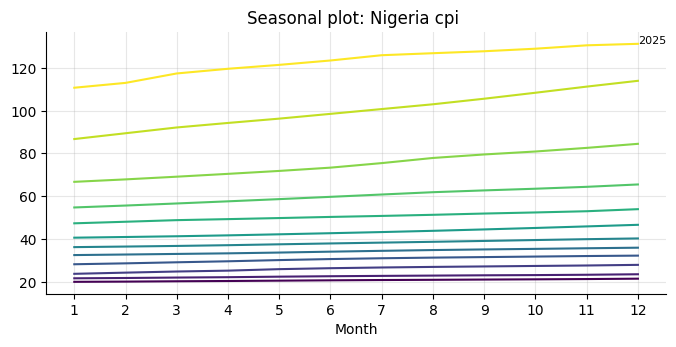

In [7]:
# Seasonal Plot for Nigeria CPI
def seasonal_plot(s, period_label='year', title=''):
    df = pd.DataFrame({'v': s.values, 'year': s.index.year, 'month': s.index.month})
    piv = df.pivot(index='month', columns='year', values='v')
    ax = piv.plot(legend=False, colormap='viridis', title=title, figsize=(8, 3.4))
    ax.set_xlabel('Month'); ax.set_xticks(range(1, 13))
    for col in piv.columns[-1:]: ax.annotate(str(col), (12, piv[col].iloc[-1]), fontsize=8)
    return ax
seasonal_plot(cpi, title='Seasonal plot: Nigeria cpi ')
plt.show()

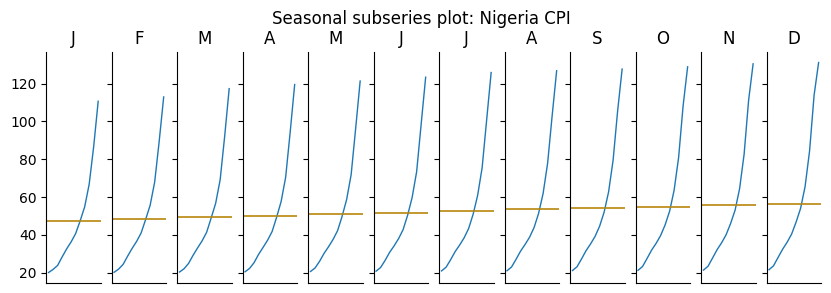

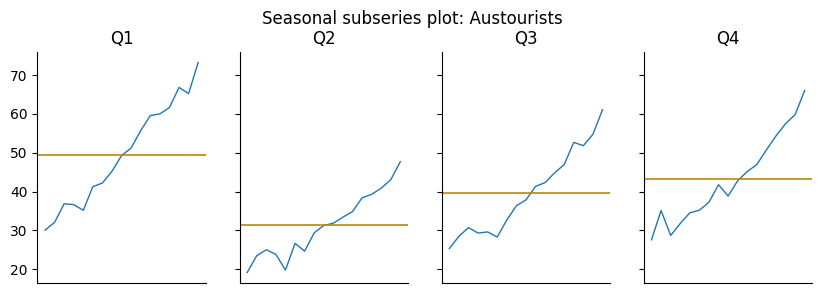

In [8]:
# Seasonal Subseries plot for both serie
def subseries_plot(s, title=''):
    is_q = s.index.freqstr.startswith('Q')
    per = s.index.quarter if is_q else s.index.month
    n = 4 if is_q else 12
    labels = ['Q1', 'Q2', 'Q3', 'Q4'] if is_q else list('JFMAMJJASOND')
    df = pd.DataFrame({'v': s.values, 'year': s.index.year, 'p': per})
    fig, axes = plt.subplots(1, n, figsize=(10, 3), sharey=True)
    for p, ax in zip(range(1, n + 1), axes):
        sub = df[df.p == p]
        ax.plot(sub.year, sub.v, lw=1)
        ax.axhline(sub.v.mean(), color='#B8860B', lw=1.2)
        ax.set_title(labels[p - 1])
        ax.set_xticks([])
        ax.grid(False)
    fig.suptitle(title, y=1.02)
    return fig

subseries_plot(cpi, title = 'Seasonal subseries plot: Nigeria CPI')
plt.show()
print()
subseries_plot(at, title = 'Seasonal subseries plot: Austourists')
plt.show()

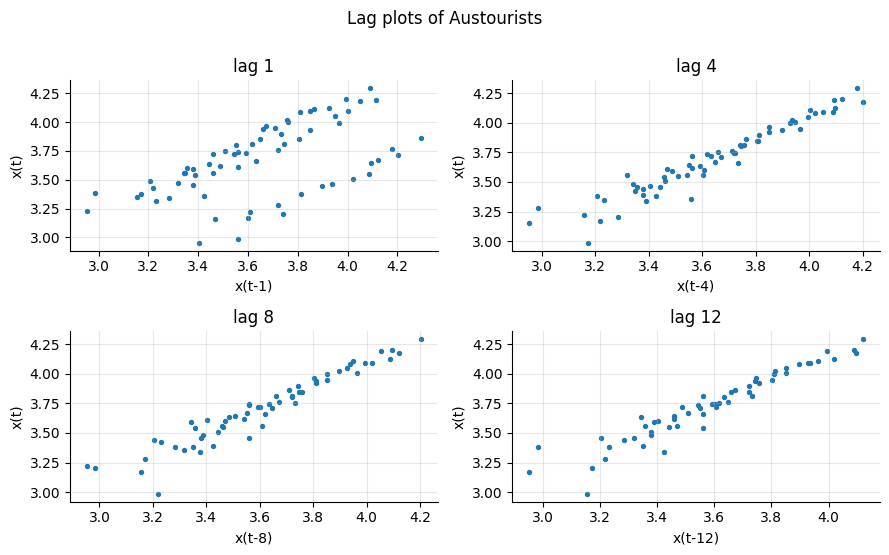

In [9]:
# Lag plot for Austourists
def lag_plot_at(s, lags=(1, 4, 8,12), title=''):
    plt.close('all')
    s = s.squeeze()
    fig, axes = plt.subplots(2, 2, figsize=(9, 5.5))
    for k, ax in zip(lags, axes.flat):
        ax.scatter(s.shift(k), s, s=8)
        ax.set_title(f'lag {k}')
        ax.set_xlabel(f'x(t-{k})')
        ax.set_ylabel('x(t)')
    fig.suptitle(title, y=1.0);
    plt.tight_layout()
    return fig

lag_plot_at(np.log(at), title='Lag plots of Austourists')
plt.show()

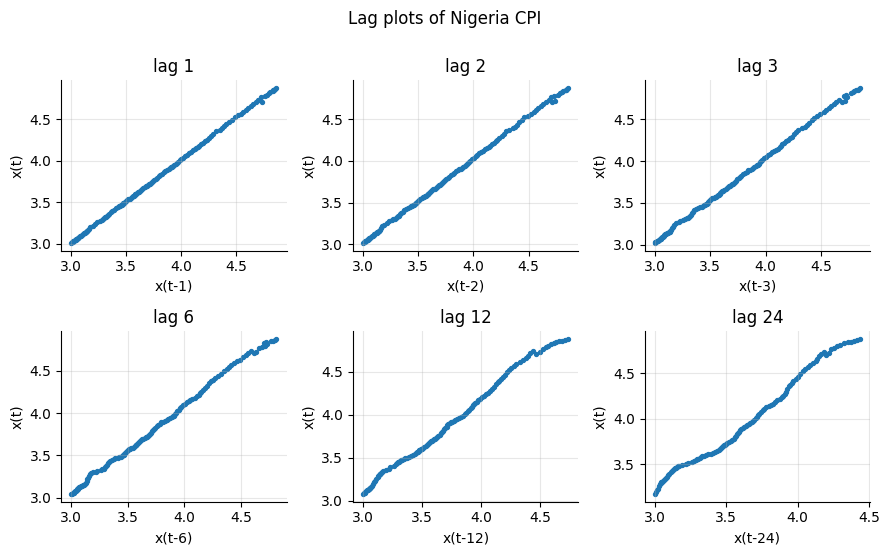

In [10]:
# Lag plot for Nigeria CPI
def lag_plot_cpi(s, lags=(1, 2, 3, 6, 12, 24), title=''):
    plt.close('all')
    s = s.squeeze()
    fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
    for k, ax in zip(lags, axes.flat):
        ax.scatter(s.shift(k), s, s=8)
        ax.set_title(f'lag {k}')
        ax.set_xlabel(f'x(t-{k})')
        ax.set_ylabel('x(t)')
    fig.suptitle(title, y=1.0);
    plt.tight_layout()
    return fig
lag_plot_cpi(np.log(cpi), title='Lag plots of Nigeria CPI')
plt.show()

Commentary:

Time Plot
*   Nigeria CPI: There is a smooth trend that accelerates, especially after 2020,so the growth is not linear. No seasonal pattern is visible

*   Austourists: There is a clear upward trend, and a strong seasonality with a peak and dip every year

Seasonal Plot
*   Nigeria CPI: No recurring seasonal pattern.

*   Austourists: Every year follows the same pattern(a very strong seasonality) Tourist numbers are highest in Q1 and falls in Q2, then recovery through Q3 and Q4.

Seasonal Subseries

*   Nigeria CPI: The mean lines are almost the same height in all 12 months. The value rise accelerate over the years(Trend).

*   Austourists: The mean line differ clearly between quarters, with the highest in the Q1 and dips in Q2 then started recoverying in Q3 and Q4. Each quarter values also rise over time.

Lag Plot
*   Nigeria CPI:Lags 1, 2 and 3 are almost perfect linear relationships. The relationship gradually weakens at lags 6, 12 and 24. No lag stands out, and lag 12 is not tighter than lag 6, so there is no seasonal pattern.

*   Austourists: Scatter of xt against x{t-k},
                 Strong positive linear relationships at every lag 4,8 and 12 (quarterly seasonality)
                 Lag 1 shows the weakest relationship.
                 The upward slope reflects the trend





## 3. ACF of each series and of its first difference

*plot_acf; interpret trend, seasonality, dependence*

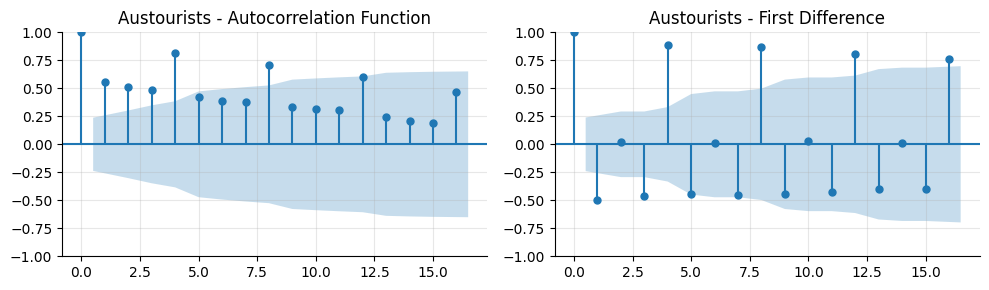

In [11]:
# ACF and First difference of austourists
from statsmodels.graphics.tsaplots import plot_acf
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(np.log(at), lags=16, ax=axes[0], title='Austourists - Autocorrelation Function');
plot_acf(np.log(at).diff().dropna(), lags=16, ax=axes[1], title='Austourists - First Difference')
plt.tight_layout()
plt.show()

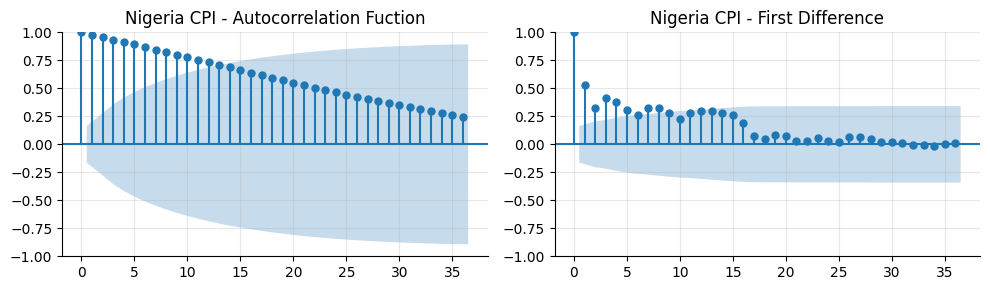

In [12]:
# ACF and First difference of Nigeria CPI
from statsmodels.graphics.tsaplots import plot_acf
plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(np.log(cpi), lags=36, ax=axes[0], title='Nigeria CPI - Autocorrelation Fuction');
plot_acf(np.log(cpi).diff().dropna(), lags=36, ax=axes[1], title='Nigeria CPI - First Difference')
plt.tight_layout()
plt.show()

Commentary
*   Nigeria CPI:The autocorrelation starts near 1 and declines very slowly and almost linearly, staying outside the confidence band for most lags. This is the signature of a strongly trending series. There is no bump at lag 12, so there is no seasonality.

*   Nigeria CPI first difference: Differencing removes most of the persistence. Autocorrelation drops to about 0.5 at lag 1 and fades to within the confidence band by about lag 15.

*   Austourists first difference: Differencing removes the slow decay, so the trend is largely gone. The seasonal pattern remains: large positive spikes at lags 4, 8, 12 and 16.

*   Austourists ACF: The autocorrelation decays slowly, which indicates a trend. It also has a peaks at lags 4, 8, 12 and 16 (the seasonal lags), which confirms strong seasonality. Lag 4 has the highest autocorrelation.



## 4. Additive or multiplicative? Justify

*evidence from the plots and the log plot*

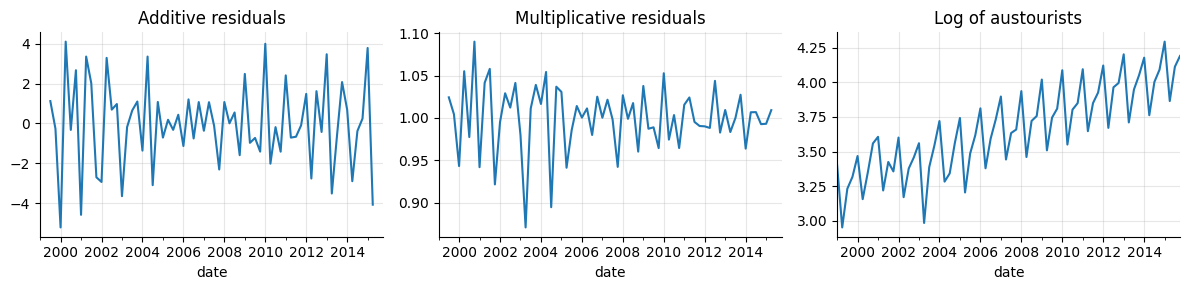

In [13]:
# For Austourists
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
plt.close('all')

add = seasonal_decompose(at, model='additive', period=4)
mul = seasonal_decompose(at, model='multiplicative', period=4)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
add.resid.plot(ax=axes[0], title='Additive residuals')
mul.resid.plot(ax=axes[1], title='Multiplicative residuals')

np.log(at).plot(title='Log of austourists')
plt.tight_layout()
plt.show()

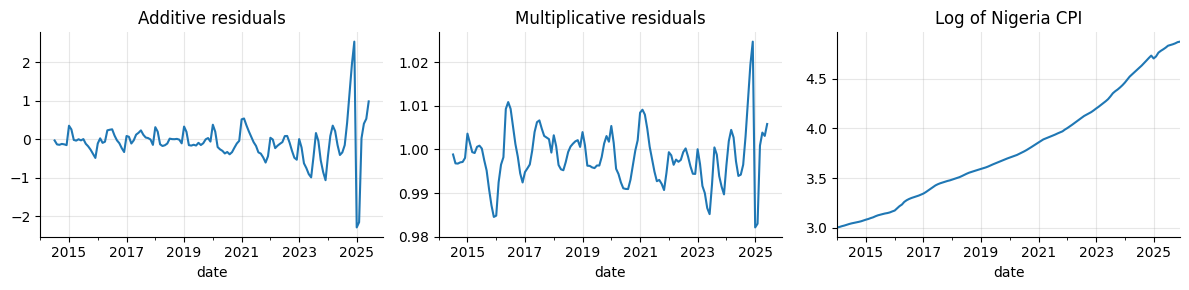

In [14]:
# For Nigeria CPI
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
plt.close('all')

add = seasonal_decompose(cpi, model='additive', period=12)
mul = seasonal_decompose(cpi, model='multiplicative', period=12)

fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=False)
add.resid.plot(ax=axes[0], title='Additive residuals')
mul.resid.plot(ax=axes[1], title='Multiplicative residuals')

np.log(cpi).plot(title='Log of Nigeria CPI')
plt.tight_layout()
plt.show()

Commentary:

•	Austourists data is multiplicative. The seasonal swings grows with the level, the log transform evens them out, and the multiplicative residuals are tighter than  the additive ones..


•	Nigeria CPI data is multiplicative. The series grow by a percentage of iys level, the log makes growth near linear, and the multiplicative residuals are small and centred on 1.

## 5. Classical and STL decomposition compared

*seasonal_decompose vs STL; where do they disagree and why*

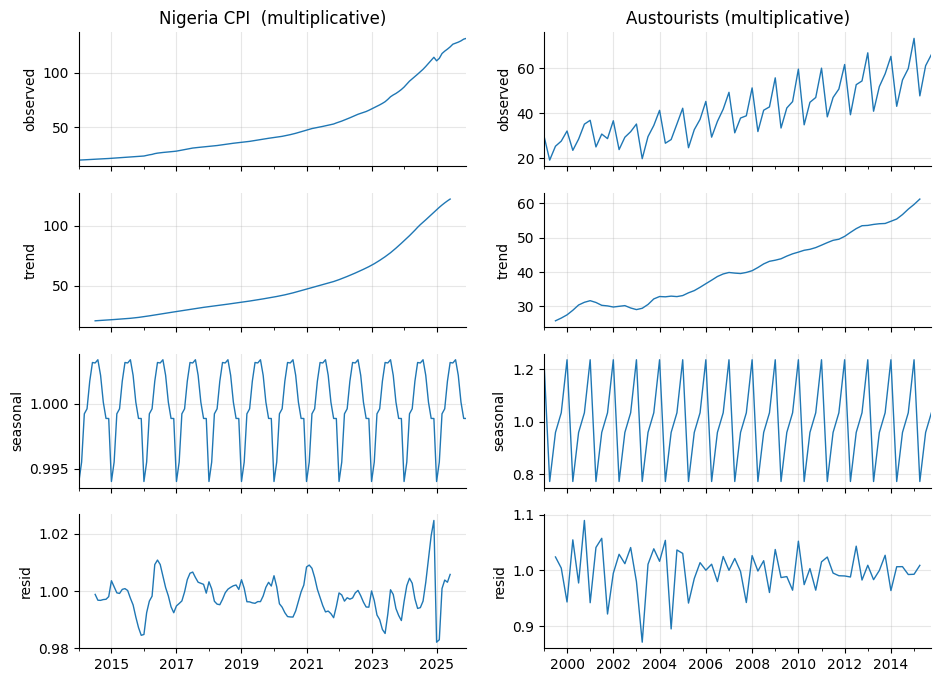

In [15]:
#Classical Decompostion
from statsmodels.tsa.seasonal import seasonal_decompose
dec_cpi  = seasonal_decompose(cpi, model='multiplicative', period=12)
dec_at = seasonal_decompose(at,   model='multiplicative', period=4)

fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex='col')
for col, (dec, name) in enumerate([(dec_cpi, 'Nigeria CPI  (multiplicative)'), (dec_at, 'Austourists (multiplicative)')]):
    for row, comp in enumerate(['observed', 'trend', 'seasonal', 'resid']):
        getattr(dec, comp).plot(ax=axes[row, col], lw=1); axes[row, col].set_ylabel(comp); axes[row, col].set_xlabel('')
    axes[0, col].set_title(name)


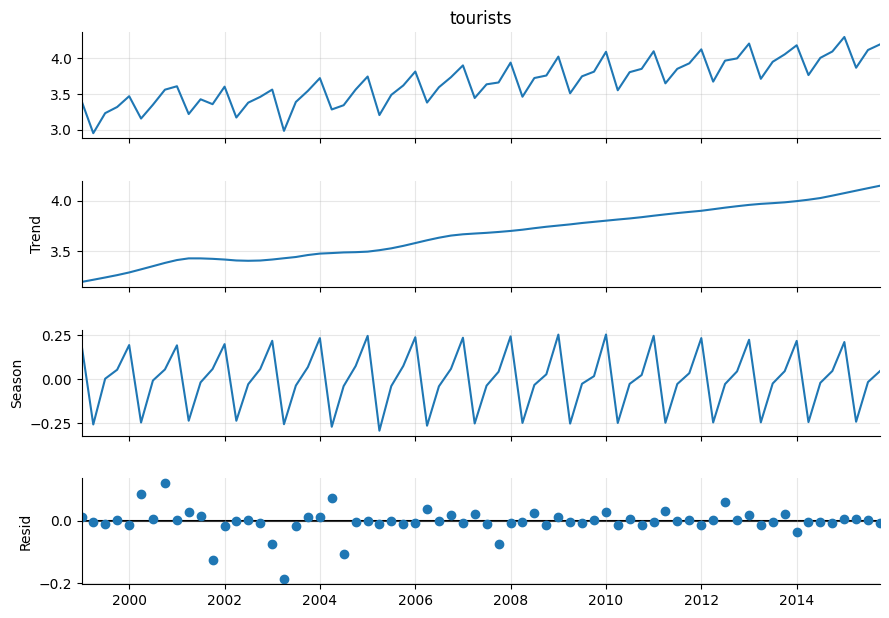

In [16]:
# STL: Seasonal-Trend decomposition using LOESS(austourists)
from statsmodels.tsa.seasonal import STL
stl_at = STL(np.log(at), period=4, seasonal=7, robust=True).fit()
fig = stl_at.plot(); fig.set_size_inches(9, 7)

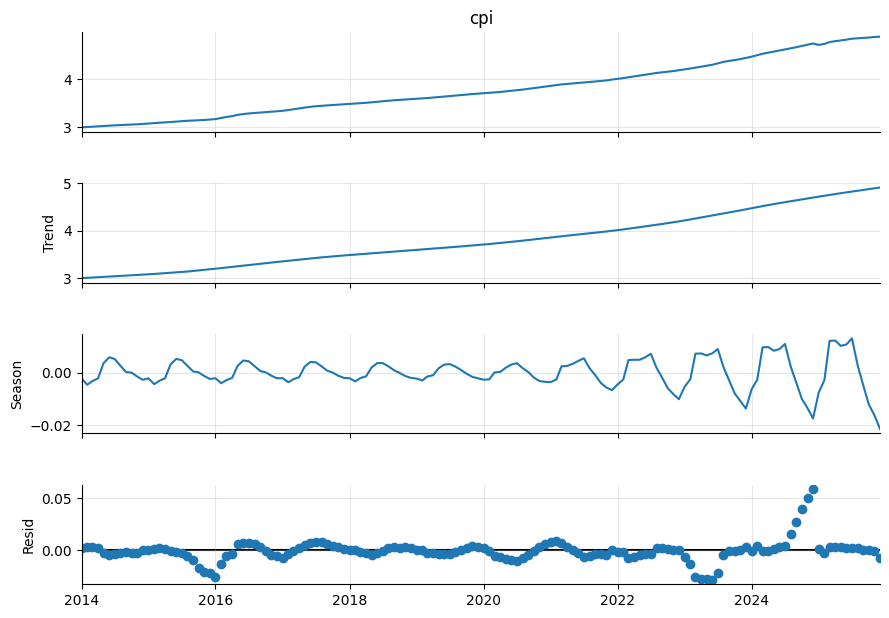

In [17]:
# STL: Seasonal-Trend decomposition using LOESS(nigeria cpi)
from statsmodels.tsa.seasonal import STL
stl_cpi = STL(np.log(cpi), period=12, seasonal=13, robust=True).fit()
fig = stl_cpi.plot(); fig.set_size_inches(9, 7)

Commentary:
*  Trend: Both methods agree on the shape. Austourists rises steadily and Nigeria CPI accelerates. The classical trend is a centred moving average, so it loses observations at both ends. STL was fitted on the log scale, so compare the shapes rather than the raw values.

*   Seasonal, austourists: The two methods agree. Both show a strong, stable quarterly pattern. The pattern barely changes over time.

*   Seasonal, Nigeria CPI: This is where they disagree most. Classical forces the same pattern every year. STL lets the seasonal component evolve. It is almost flat before about 2020 and grows to about ±0.02 in logs by 2023-2025.

*   Why they disagree: Classical assumes a fixed seasonal pattern and a moving-average trend, so it cannot show change over time. STL smooths the seasonal component locally, so it can drift. The recent growth in CPI seasonality is probably not real seasonality.




## 6. Transformation decision

*log / Box-Cox; show the effect*

MLE Box-Cox lambda for austourists: 0.082  (0 = log)


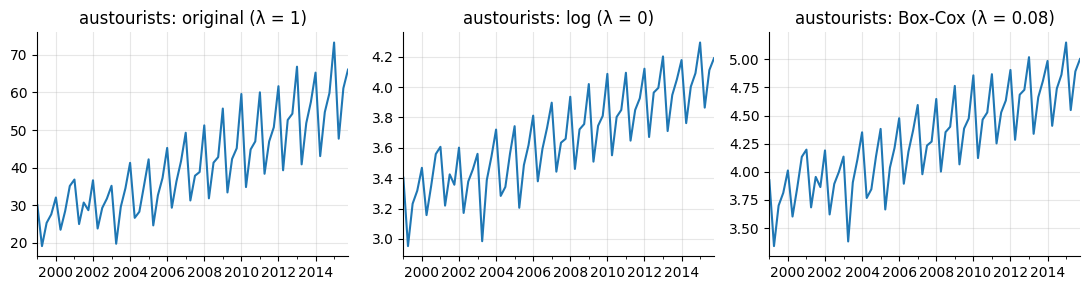

In [18]:
#Transformation of the Austourists data
from scipy import stats

lam = stats.boxcox_normmax(at.values, method='mle')
print(f'MLE Box-Cox lambda for austourists: {lam:.3f}  (0 = log)')
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
at.plot(ax=axes[0], title='austourists: original (λ = 1)')
np.log(at).plot(ax=axes[1], title='austourists: log (λ = 0)')
pd.Series(stats.boxcox(at.values, lmbda=lam), index=at.index).plot(ax=axes[2], title=f'austourists: Box-Cox (λ = {lam:.2f})')
for ax in axes: ax.set_xlabel('')

plt.tight_layout()
plt.show()


MLE Box-Cox lambda for nigeria cpi: -0.429  (0 = log)


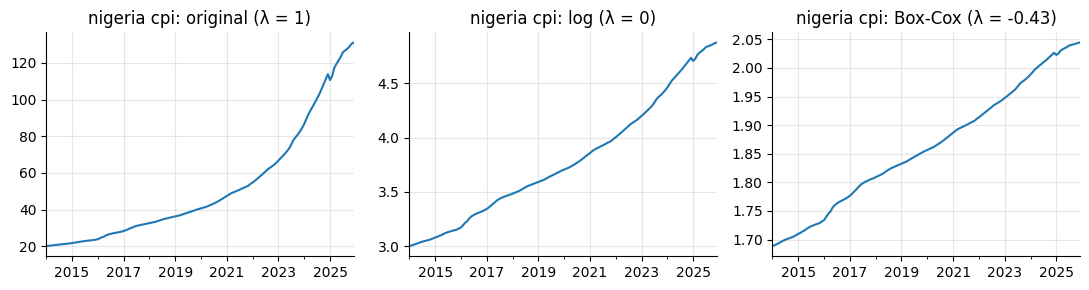

In [19]:
#Transformation of the Nigeria CPI data
from scipy import stats
lam = stats.boxcox_normmax(cpi.values, method='mle')
print(f'MLE Box-Cox lambda for nigeria cpi: {lam:.3f}  (0 = log)')
fig, axes = plt.subplots(1, 3, figsize=(11, 3))
cpi.plot(ax=axes[0], title='nigeria cpi: original (λ = 1)')
np.log(cpi).plot(ax=axes[1], title='nigeria cpi: log (λ = 0)')
pd.Series(stats.boxcox(cpi.values, lmbda=lam), index=cpi.index).plot(ax=axes[2], title=f'nigeria cpi: Box-Cox (λ = {lam:.2f})')
for ax in axes: ax.set_xlabel('')

plt.tight_layout()
plt.show()

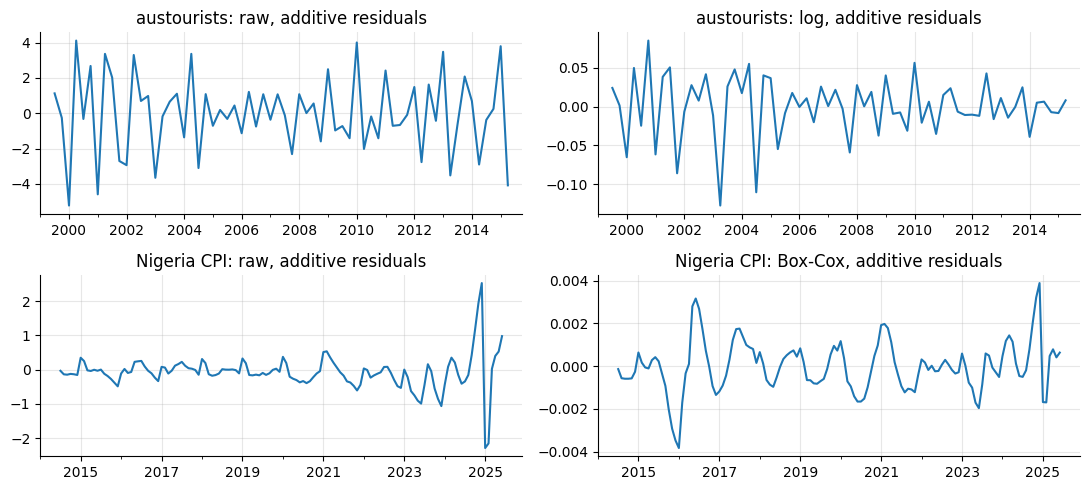

In [20]:
#Classical Decompostion After Transformation
from statsmodels.tsa.seasonal import seasonal_decompose
cpi_bc = pd.Series(stats.boxcox(cpi.values, lmbda=-0.429), index=cpi.index)

cases = [('austourists', at, np.log(at), 'log', 4),
         ('Nigeria CPI', cpi, cpi_bc, 'Box-Cox', 12)]

fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for i, (name, raw, tr, tlabel, p) in enumerate(cases):
    seasonal_decompose(raw, model='additive', period=p).resid.plot(
        ax=axes[i, 0], title=f'{name}: raw, additive residuals')
    seasonal_decompose(tr, model='additive', period=p).resid.plot(
        ax=axes[i, 1], title=f'{name}: {tlabel}, additive residuals')
    for ax in axes[i]:
        ax.set_xlabel('')
plt.tight_layout()
plt.show()

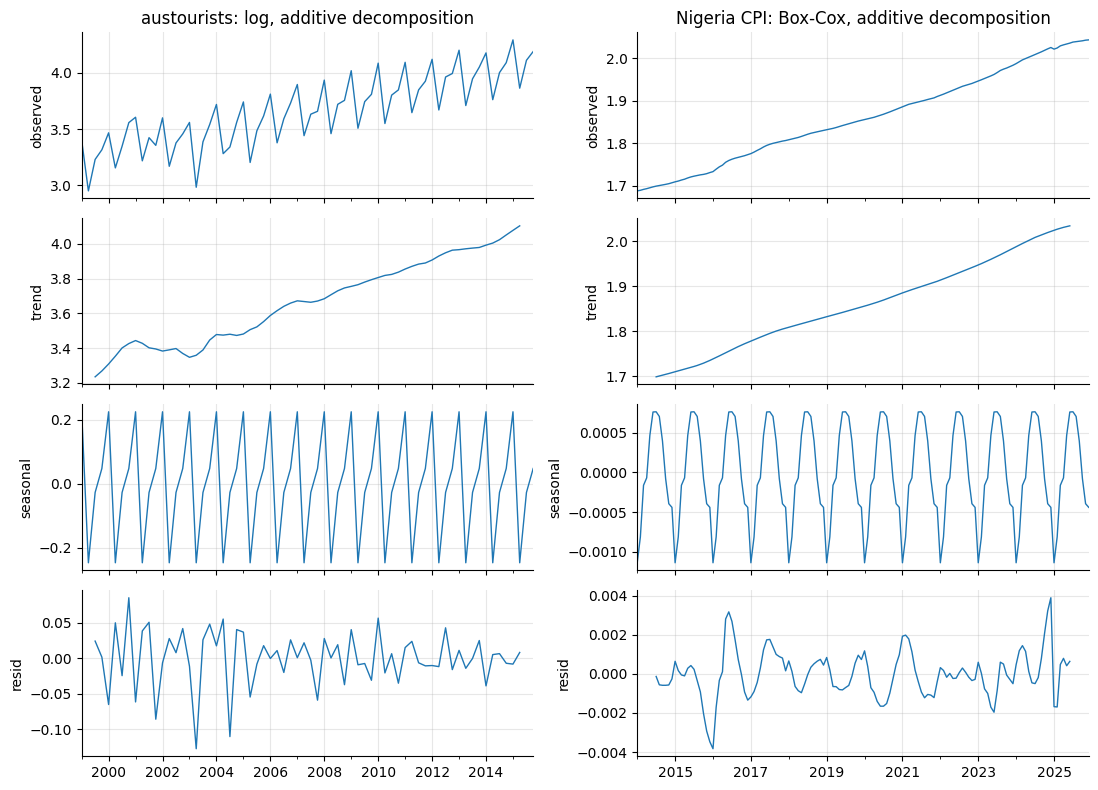

In [21]:
fig, axes = plt.subplots(4, 2, figsize=(11, 8), sharex='col')
for col, (name, raw, tr, tlabel, p) in enumerate(cases):
    dec = seasonal_decompose(tr, model='additive', period=p)
    for row, comp in enumerate(['observed', 'trend', 'seasonal', 'resid']):
        getattr(dec, comp).plot(ax=axes[row, col], lw=1)
        axes[row, col].set_ylabel(comp)
        axes[row, col].set_xlabel('')
    axes[0, col].set_title(f'{name}: {tlabel}, additive decomposition')
plt.tight_layout()
plt.show()

Commentary:

•	Austourists: The seasonal swings in the raw series grow with the level,so the variance is not constant. The Box-Cox λ is 0.082, close to 0, so a log transform is appropriate. After logging, the seasonal component has a constant amplitude across all years, and the additive residuals are small. The decomposition is now additive on the log scale, which is equivalent to multiplicative on the original scale. Transformation warranted (log).

•	Nigeria CPI: The raw series grows at an accelerating rate. The Box-Cox λ is -0.43, well away from 0, so a log alone would under-correct, and the log series still curves upward. After Box-Cox, the trend is close to linear and the residuals stay in a narrow, even band. The seasonal component is negligible, so the gain comes from the trend and the residual spread, not from seasonality. Transformation warranted (Box-Cox).

Effect of the transformation on the decomposition:

*   Austourists (log): In the raw decomposition, the additive residuals are large and patterned. After the log, the seasonal component has a constant amplitude in every year, and the residuals are small and more random. The seasonal swings no longer grow with the level, so an additive decomposition of the log series fits.

*   Nigeria CPI (Box-Cox): In the raw decomposition, the additive residuals widen over time. After Box-Cox, the trend is close to a straight line and the residuals stay within a narrow, even band, with no widening funnel. The seasonal component stays negligible. The improvement comes from the trend and the residual spread, not from seasonality. A small spike near 2025 remains, so it is a genuine shock rather than a scaling problem.



## 7. Seasonally adjusted series

*adjust on the right scale*

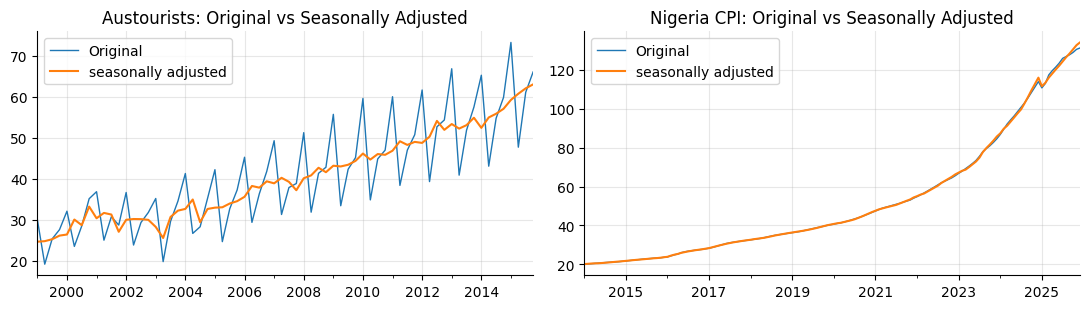

In [22]:
cpi = tsdata.nigeria_cpi()
stl_cpi = STL(np.log(cpi), period=12, seasonal=13, robust=True).fit()
cpi_sa = np.exp(np.log(cpi) - stl_cpi.seasonal)
at_sa = np.exp(np.log(at) - stl_at.seasonal)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
at.plot(ax=axes[0], label='Original', lw=1)
at_sa.plot(ax=axes[0], label='seasonally adjusted', lw=1.5)
axes[0].set_title('Austourists: Original vs Seasonally Adjusted')
axes[0].legend()
axes[0].set_xlabel('')
cpi.plot(ax=axes[1], label='Original', lw=1)
cpi_sa.plot(ax=axes[1], label='seasonally adjusted', lw=1.5)
axes[1].set_title('Nigeria CPI: Original vs Seasonally Adjusted')
axes[1].legend()
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()


Commentary:
*   Austourists: Seasonal adjustment removes the strong quarterly zigzag. The adjusted series is much smoother than the original and shows the underlying steady upward trend.
*   Nigeria CPI: The adjusted series almost coincides with the original, so seasonal adjustment changes very little. This matches the earlier findings of no seasonality. The accelerating upward trend is unchanged.


## 8. Strength of trend and seasonality

*compute for both series and compare*

In [23]:
def strength_features(s, period, seasonal, log=False):
    y = np.log(s) if log else s
    r = STL(y, period=period, seasonal=seasonal, robust=True).fit()
    ft = max(0, 1 - r.resid.var() / (r.trend + r.resid).var())
    fs = max(0, 1 - r.resid.var() / (r.seasonal + r.resid).var())
    return round(ft, 3), round(fs, 3)

rows = []
for name, s, p, sea, lg in [('Austourists', at, 4, 7, True),
                            ('Nigeria CPI (sim.)', cpi, 12, 13, True),
                            ('White noise',
                             pd.Series(np.random.default_rng(3).normal(size=len(at)), index=at.index),
                             4, 7, False)]:
    ft, fs = strength_features(s, p, sea, lg)
    rows.append((name, ft, fs))
print(pd.DataFrame(rows, columns=['series', 'trend strength', 'seasonal strength']).to_string(index=False))


            series  trend strength  seasonal strength
       Austourists           0.975              0.945
Nigeria CPI (sim.)           1.000              0.000
       White noise           0.000              0.022


Commentary:

*   Austourists has strong trend and strong seasonality.

*   Nigeria CPI is almost pure trend, with no seasonality. This matches the earlier decomposition and the seasonally adjusted plot, where the adjusted and original series nearly coincide.

*   White noise (the reference) has its trend is absent and its seasonality is small. Austourists is far above that baseline, so its seasonality is real.

*   Comparison: Both real series are trend-dominated, but only austourists is seasonal. CPI's trend is stronger than austourists, while austourists' seasonality is much stronger than CPI's. Seasonal adjustment therefore matters for austourists but not for CPI.



## 9. Narratives (one page per series, also in the PDF report)

*what the series is doing; regularities; events or breaks; what a forecaster should worry about*

In [24]:
# code


Commentary:

## AI-use statement

(Two to five lines: which tools, for what. 'No AI tools were used' is acceptable.)